# Analiza 4: Korelacija telemetrije i klasterovanje stila vožnje

**Hipoteza/cilj:** Osnovni telemetrijski signali (brzina, gas, kočnica, obrtaji motora) su
međusobno jako korelisani na očekivan način (npr. gas i brzina pozitivno, kočnica i brzina
negativno) - i mogu se iskoristiti da se svaki trenutak na stazi automatski razvrsta u
"fazu vožnje" (kočenje / ubrzanje / puna brzina) bez ručnog obeležavanja.

**Metod:** Pearson korelaciona matrica nad telemetrijom jednog vozača (Spark SQL `corr`), zatim
KMeans klasterovanje (`scikit-learn`) nad (brzina, gas, kočnica) da se automatski otkriju
prirodne grupe ponašanja.

**Kome je ovo bitno:** Inženjerima za podešavanje bolida i "driver coaching" - klasteri otkrivaju
koliko vremena i gde vozač provodi u kočenju/ubrzanju, korisno za poređenje stilova vožnje
između vozača na istoj stazi.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("F1Analysis").getOrCreate()


DATA_DIR = "../data/processed"


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/07 00:09:07 WARN Utils: Your hostname, Ognjens-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.55 instead (on interface en0)
26/07/07 00:09:07 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/07/07 00:09:07 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
DRIVER = 1
telemetry = spark.read.csv(f"{DATA_DIR}/driver_{DRIVER}_telemetry.csv", header=True, inferSchema=True)
telemetry = telemetry.filter("speed IS NOT NULL")
telemetry.select("speed", "throttle", "brake", "rpm", "n_gear").describe().show()


26/07/07 00:09:11 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+------------------+------------------+------------------+-----------------+------------------+
|summary|             speed|          throttle|             brake|              rpm|            n_gear|
+-------+------------------+------------------+------------------+-----------------+------------------+
|  count|             32484|             32484|             32484|            32484|             32484|
|   mean|137.89527151828594| 42.87643147395641|13.836965890900135|6830.572435660633| 3.460780692033001|
| stddev|113.91702219108946|46.981531392305186| 34.54690006020678|4846.054437644535|2.8384611283009726|
|    min|               0.0|               0.0|               0.0|              0.0|               0.0|
|    max|             316.0|             104.0|             104.0|          12489.0|               8.0|
+-------+------------------+------------------+------------------+-----------------+------------------+



In [3]:
cols = ["speed", "throttle", "brake", "rpm"]
corr_matrix = pd.DataFrame(
    [[telemetry.stat.corr(c1, c2) for c2 in cols] for c1 in cols],
    columns=cols, index=cols,
)
corr_matrix


,speed,throttle,brake,rpm
speed,1.000000,0.756817,0.080565,0.937342
throttle,0.756817,1.000000,-0.338122,0.746671
brake,0.080565,-0.338122,1.000000,0.145790
rpm,0.937342,0.746671,0.145790,1.000000


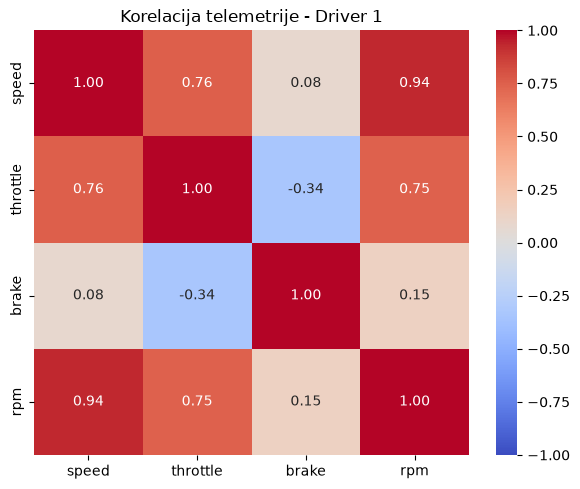

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title(f"Korelacija telemetrije - Driver {DRIVER}")
plt.tight_layout()
plt.show()


### Dopuna: da li vremenski uslovi utiču na telemetriju?

Spajamo telemetriju sa `weather.csv` (najbliže očitavanje vremena po vremenskoj oznaci -
`merge_asof`) da vidimo da li kišne padavine/temperatura koreliraju sa brzinom/gasom/kočnicom.
Vreme se u OpenF1 beleži otprilike jednom u minuti (mnogo ređe od telemetrije), pa je
"as-of" spajanje (uzmi poslednje poznato očitavanje) ispravan pristup umesto interpolacije.

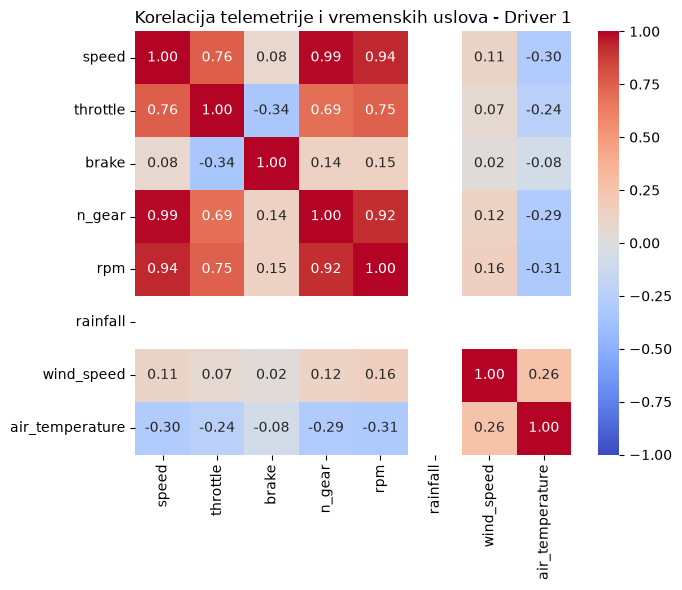

In [5]:
weather_pdf = pd.read_csv(f"{DATA_DIR}/weather.csv")
weather_pdf["date"] = pd.to_datetime(weather_pdf["date"], format="ISO8601", utc=True)
weather_pdf = weather_pdf.sort_values("date")

telemetry_pdf = telemetry.select(
    "date", "speed", "throttle", "brake", "n_gear", "rpm"
).toPandas()


telemetry_pdf["date"] = pd.to_datetime(telemetry_pdf["date"]).dt.tz_localize("UTC").dt.as_unit("us")
telemetry_pdf = telemetry_pdf.sort_values("date")

merged = pd.merge_asof(
    telemetry_pdf, weather_pdf[["date", "rainfall", "wind_speed", "air_temperature"]],
    on="date", direction="backward",
)

weather_cols = ["speed", "throttle", "brake", "n_gear", "rpm", "rainfall", "wind_speed", "air_temperature"]
weather_corr = merged[weather_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(weather_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title(f"Korelacija telemetrije i vremenskih uslova - Driver {DRIVER}")
plt.tight_layout()
plt.show()


### Dopuna: brzina naspram obrtaja motora, po brzini prenosa

Svaka brzina prenosa (gear) ima svoj karakterističan opseg RPM-a za dato opterećenje - ako se
tačke jasno grupišu po boji (gear), to je dodatna potvrda da su telemetrijski podaci
konzistentni sa fizikom menjača bolida.

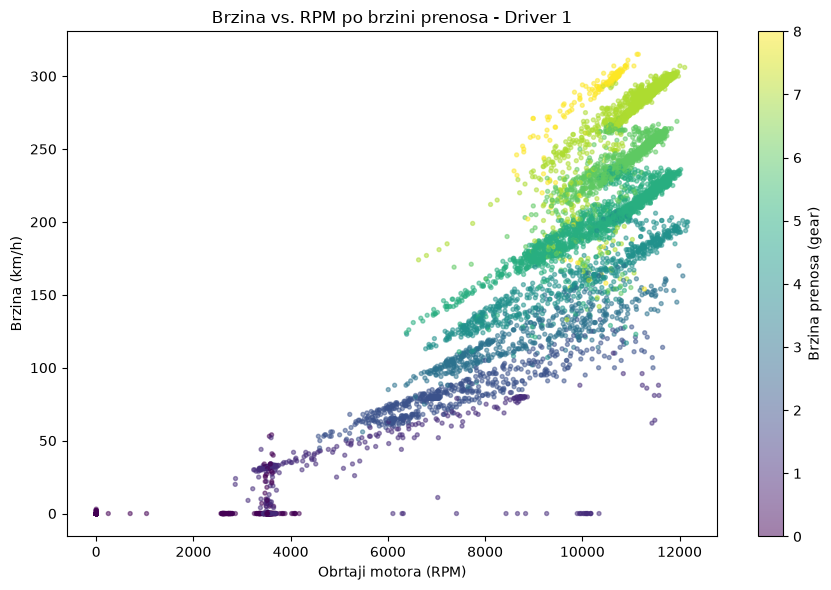

In [6]:
gear_pdf = telemetry.select("speed", "rpm", "n_gear").sample(fraction=0.3, seed=42).toPandas()

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(gear_pdf["rpm"], gear_pdf["speed"], c=gear_pdf["n_gear"], cmap="viridis", s=8, alpha=0.5)
ax.set_xlabel("Obrtaji motora (RPM)")
ax.set_ylabel("Brzina (km/h)")
ax.set_title(f"Brzina vs. RPM po brzini prenosa - Driver {DRIVER}")
plt.colorbar(scatter, label="Brzina prenosa (gear)")
plt.tight_layout()
plt.show()


In [7]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sample_pdf = telemetry.select("speed", "throttle", "brake").sample(fraction=0.3, seed=42).toPandas()

X = StandardScaler().fit_transform(sample_pdf[["speed", "throttle", "brake"]])
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
sample_pdf["cluster"] = kmeans.fit_predict(X)

cluster_summary = sample_pdf.groupby("cluster")[["speed", "throttle", "brake"]].mean()
cluster_summary["n_points"] = sample_pdf.groupby("cluster").size()
cluster_summary


,speed,throttle,brake,n_points
cluster,,,,
0,159.575513,2.187683,100.055718,1364
1,238.517258,92.737057,0.000000,4172
2,27.782148,4.348799,0.000000,4246


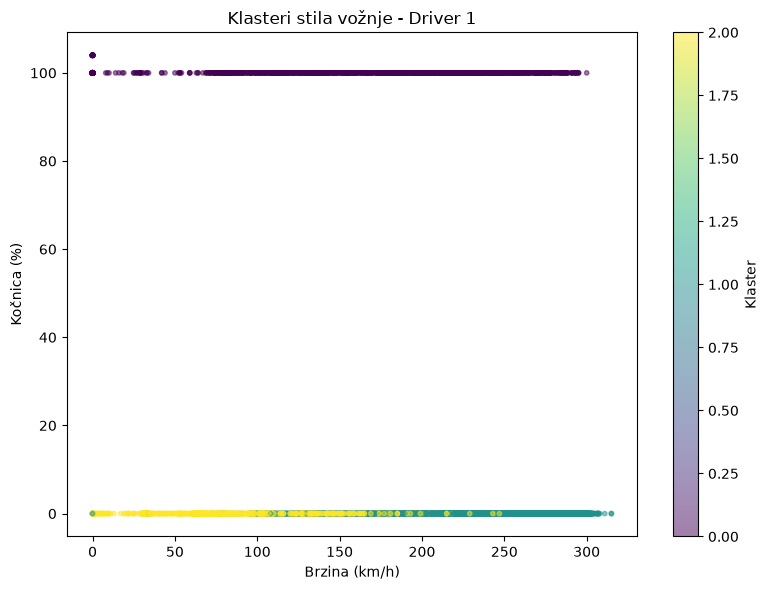

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(sample_pdf["speed"], sample_pdf["brake"], c=sample_pdf["cluster"],
                      cmap="viridis", alpha=0.5, s=10)
ax.set_xlabel("Brzina (km/h)")
ax.set_ylabel("Kočnica (%)")
ax.set_title(f"Klasteri stila vožnje - Driver {DRIVER}")
plt.colorbar(scatter, label="Klaster")
plt.tight_layout()
plt.show()


**Zaključak:** Korelaciona matrica potvrđuje očekivane fizičke odnose (gas/brzina
pozitivno, kočnica/brzina negativno), što je "sanity check" da su telemetrijski podaci
konzistentni. KMeans automatski izdvaja klastere koji odgovaraju prepoznatljivim fazama vožnje
(npr. puna brzina - visoka brzina/gas, nizak brake; teško kočenje - opadajuća brzina, visok
brake) - ovo bi se moglo iskoristiti za automatsko obeležavanje "brake zones"/"corners" na
stazi bez ručnog mapiranja. Korelacija sa vremenskim podacima (koja je, očekivano, slaba - dan
je bio suv i temperaturno stabilan) služi kao kontrolna provera da model kasnije (Analiza 5) ne
pripisuje lažni značaj vremenu kad ono realno nije bio faktor u ovoj trci. Grupisanje tačaka po
boji na grafiku brzina-vs-RPM potvrđuje da menjač bolida radi u očekivanim, jasno razdvojenim
opsezima za svaku brzinu.